# This file for developing the CNN-LSTM Bean leaf disease classifier
by using original, augmented datasets

### Check Environment

In [157]:
# !cat /proc/cpuinfo | grep "model name" | head -1

In [158]:
# !cat /etc/*release

In [159]:
# !nvidia-smi

# Imports

In [160]:
import numpy as np
import pandas as pd
import tensorflow as tf
assert tf.__version__.startswith('2')
#import keras
import random
import itertools
import os
import matplotlib.pyplot as plt
from google.colab import files, drive
#from re import X

from sklearn.metrics import matthews_corrcoef, confusion_matrix, f1_score

%matplotlib inline

In [161]:
print(tf.version.VERSION)

2.17.0


#### Set random seeds

In [162]:
# Random seeds
random.seed(111)
np.random.seed(111)
tf.random.set_seed(111)

In [163]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [164]:
WIDTH = 300 # image width
HEIGHT = 300  #image height
CHANNELS = 3
SHAPE = (WIDTH, HEIGHT, CHANNELS)
IMAGE_SIZE = [WIDTH, HEIGHT]
TOTAL_INPUTS = WIDTH * HEIGHT * CHANNELS
LABELS = ['Angular Leaf Spot', 'Bean Rust', 'Healthy']

# total number of training samples
TRAIN = 905
AUG_SAMPLES = 2715
MODEL = 'CNN-LSTM: '

# Total samples of images
SAMPLES = 1295
CLASSES = 3
#  Parameter values
BATCH = [16, 32, 64]
LEARNING_RATE = [1e-4, 1e-3, 1e-2]
#NEURONS = [CLASSES, 16, 32, 64, 128]

# Original data file names
X_TRAIN = 'x_train_original.npy'  #905
X_VAL = 'x_val.npy'  # 195
X_TEST = 'x_test.npy'  #195
Y_TRAIN = 'y_train_original.npy'  #905
Y_VAL = 'y_val.npy'  #195
Y_TEST = 'y_test.npy'  #195

# Transformed data file names
# X_TRAIN_ROTATE = 'x_train_rotate.npy'
# Y_TRAIN_ROTATE = 'y_train_rotate.npy'
# X_TRAIN_FLIP = 'x_train_flip.npy'
# Y_TRAIN_FLIP = 'y_train_flip.npy'
# X_TRAIN_CROP = 'x_train_crop.npy'
# Y_TRAIN_CROP = 'y_train_crop.npy'
# X_TRAIN_BRIGHT = 'x_train_bright.npy'
# Y_TRAIN_BRIGHT = 'y_train_bright.npy'


# Load data
from files
####Note: variables x_train and y_train are reused for all training sets, validation and test sets are the same for all training

In [165]:
### Original dataset
x_train = np.load('/content/drive/MyDrive/Colab Notebooks/'+ X_TRAIN)
y_train = np.load('/content/drive/MyDrive/Colab Notebooks/'+ Y_TRAIN)

x_val = np.load('/content/drive/MyDrive/Colab Notebooks/'+ X_VAL)
y_val = np.load('/content/drive/MyDrive/Colab Notebooks/'+ Y_VAL)

x_test = np.load('/content/drive/MyDrive/Colab Notebooks/'+ X_TEST)
y_test = np.load('/content/drive/MyDrive/Colab Notebooks/'+ Y_TEST)


In [166]:
# Reshape feature array into 3-dim
x_train = np.reshape(x_train, (-1, HEIGHT, WIDTH, CHANNELS))
x_val = np.reshape(x_val, (-1, HEIGHT, WIDTH, CHANNELS))
x_test = np.reshape(x_test, (-1, HEIGHT, WIDTH, CHANNELS))

## Normalise data

In [167]:
x_train = x_train/255.0
x_test = x_test/255.0
x_val = x_val/255.0

In [168]:
#  Check the dimension
print(f'x_train= {x_train.shape}, x_val = {x_val.shape}, x_test = {x_test.shape}')

x_train= (905, 300, 300, 3), x_val = (195, 300, 300, 3), x_test = (195, 300, 300, 3)


# Core functions

In [169]:

# show sample images
def sample_random_images(nums):
  fig = plt.figure(figsize=(10, 10))
  for i in range(len(nums)):
    ax = plt.subplot(3, 3, i+1)
    # get label name
    plt.title(LABELS[y_train[nums[i]]])
    # get image
    plt.imshow((x_train[nums[i]]))
    plt.axis('off')


# Confusion matrix function testing
def produce_confusion_matrix(y_test, prediction, classes, labels, normalize=False):
    cm = confusion_matrix(y_true=y_test, y_pred=prediction)
    rows = cm.shape[0]
    cols = cm.shape[1]

    cmap=plt.cm.Greys
    title='Confusion Matrix'
    if normalize:
        cm = cm.astype('float')/cm.sum(axis=1)[:, np.tf.newaxis]
        print('Normalized confusion matrix')
    else:
        print('Confusion matrix without normalization')

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title, fontsize=17)
    plt.colorbar()
    tick_marks = np.arange(classes)
    plt.xticks(tick_marks, labels, rotation=45, fontsize=14)
    plt.yticks(tick_marks, labels, fontsize=14)

    fmt = '.2f' if normalize else 'd'

    for i, j in itertools.product(range(rows), range(cols)):
        plt.text(j, i, format(cm[i, j], fmt),
                horizontalalignment='center',
                color='white' if (cm[i,j] > cm.max() / 2.) else 'black')
    plt.tight_layout()
    plt.ylabel('Actual Label', fontsize=15)
    plt.xlabel('Predicted Label', fontsize=15)
    return cm


# Precision
def get_precision(cm):
  true_pos = np.diag(cm)
  score = true_pos / np.sum(cm, axis=0) # true pos + true neg
  print(f'Precision score = {score}')
  return score

# Recall
def get_recall(cm):
  true_pos = np.diag(cm)
  score = true_pos / np.sum(cm, axis=1) # true pos + false neg
  print(f'Recall score = {score}')
  return score


# F1-score
def get_f_1_score(cm, y_true, y_hat):
    """
    this computes unweighted F1 scores: by class and averaged unweighted
    also prints out precision and recall scores for each class
    """
    recall = get_recall(cm)
    precision = get_precision(cm)

    avg_recall = np.mean(recall)
    avg_prec = np.mean(precision)

    f1 = 2 * ((avg_recall * avg_prec) / (avg_recall + avg_prec))
    print(f'Unweighted F1 Score: {f1}')
    print(f'F1 score for each class :{f1_score(y_true, y_hat, average=None)}')

    weighted_f1 = f1_score(y_true, y_hat, average='weighted')
    print(f'Weighted overall F1: {weighted_f1}')


# MCC
def get_mcc(y, y_hat):
  mcc = matthews_corrcoef(y, y_hat)
  print(f'MCC is {mcc}')


def show_mis_predicted_img(prediction, labels, x=x_test, y=y_test):
   missed_id = np.where(p != y)[0]
   i = np.random.choice(missed_id)
  #  plt.imshow(x[i].reshape(px, px)) # necesaary for the grayscale img
   plt.title(f'True Label: {labels[y_test[i]]},\n Predicted: {labels[prediction[i]]}',
             fontsize=15);
   plt.imshow(x[i], cmap='gray')
   plt.axis('off')

def show_image(data):
    if data is not None:
        plt.imshow(data)
        plt.axis('off')
    else:
        print('No image to show')


def generate_performance_graph(value_1, value_2,
                               label_1, label_2,
                               title,
                               c1='navy', c2='lightseagreen'):
  plt.figure(figsize=(9,5))
  plt.title(MODEL+title, fontsize=16)
  plt.xlabel('Number of epochs', fontsize=14)
  plt.ylabel(title, fontsize=14)
  plt.plot(value_1, label=label_1, c=c1, linewidth=3, alpha=0.8)
  plt.plot(value_2, label=label_2, c=c2, linewidth=3, alpha=0.8)
  plt.legend(prop={'size':14})



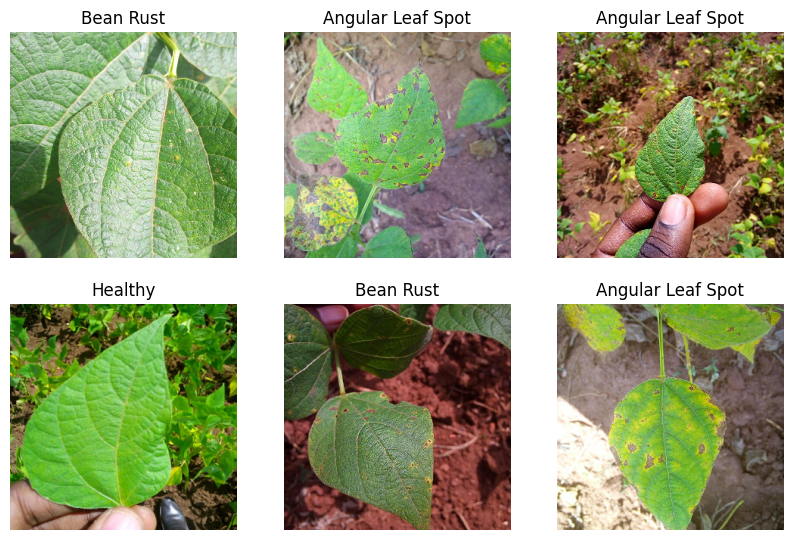

In [170]:
 # Random samples must show the same images across models using the augmented datasets
sample_random_images(nums=[np.random.randint(1, TRAIN) for x in range(6)])

# Model CNN-LSTM

In [171]:
# Finalised model DO NOT CHANGE
# Common Convolution layer : ** DO NOT CHANGE ***
i = tf.keras.layers.Input(shape=x_train[0].shape)
x = tf.keras.layers.Conv2D(filters=32, kernel_size=(3,3),strides=2, activation='relu', kernel_initializer='he_normal', padding='same')(i)
x = tf.keras.layers.Conv2D(filters=32, kernel_size=(3,3),strides=2, activation='relu', kernel_initializer='he_normal', padding='same')(x)
#
x = tf.keras.layers.Conv2D(filters=32, kernel_size=(3,3),strides=1, activation='relu', kernel_initializer='he_normal', padding='same')(x)
x = tf.keras.layers.Conv2D(filters=32, kernel_size=(3,3),strides=1, activation='relu', kernel_initializer='he_normal', padding='same')(x)
x = tf.keras.layers.MaxPooling2D((2, 2), padding='same')(x)
#
x = tf.keras.layers.Conv2D(filters=64, kernel_size=(3,3),strides=1, activation='relu', kernel_initializer='he_normal', padding='same')(x)
x = tf.keras.layers.Conv2D(filters=64, kernel_size=(3,3),strides=1, activation='relu', kernel_initializer='he_normal', padding='same')(x)
x = tf.keras.layers.MaxPooling2D((2, 2), padding='same')(x)
#
x = tf.keras.layers.Conv2D(filters=64, kernel_size=(2,2),strides=1, activation='relu', kernel_initializer='he_normal', padding='same')(x)
x = tf.keras.layers.Conv2D(filters=64, kernel_size=(2,2),strides=1, activation='relu', kernel_initializer='he_normal', padding='same')(x)
x = tf.keras.layers.MaxPooling2D((2, 2), padding='same')(x)

# End of the convolution layers

# LSTM
x = tf.keras.layers.Reshape((-1, 64))(x)
#x = tf.keras.layers.Reshape((-1, x.shape[-1]))(x) # same as above
x = tf.keras.layers.LSTM(units=64, return_sequences=True)(x)
x = tf.keras.layers.Dropout(0.5)(x)
x = tf.keras.layers.LSTM(units=16)(x)
x = tf.keras.layers.Dropout(0.4)(x)
x = tf.keras.layers.Dense(CLASSES, activation='softmax')(x)

model = tf.keras.models.Model(i, x)
model.summary()

Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)          │ (None, 300, 300, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_88 (Conv2D)                   │ (None, 150, 150, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_89 (Conv2D)                   │ (None, 75, 75, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_90 (Conv2D)                   │ (None, 75, 75, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_91 (Conv2D)                   │ (None, 75, 75, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_33 (MaxPooling2D)      │ (None, 38, 38, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_92 (Conv2D)                   │ (None, 38, 38, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_93 (Conv2D)                   │ (None, 38, 38, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_34 (MaxPooling2D)      │ (None, 19, 19, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_94 (Conv2D)                   │ (None, 19, 19, 64)          │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_95 (Conv2D)                   │ (None, 19, 19, 64)          │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_35 (MaxPooling2D)      │ (None, 10, 10, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape_12 (Reshape)                 │ (None, 100, 64)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_22 (LSTM)                       │ (None, 100, 64)             │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_22 (Dropout)                 │ (None, 100, 64)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_23 (LSTM)                       │ (None, 16)                  │           5,184 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_23 (Dropout)                 │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 3)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 155,219 (606.32 KB)

 Trainable params: 155,219 (606.32 KB)

 Non-trainable params: 0 (0.00 B)

In [172]:
# Common settings for all models: DO NOT CHANGE
# Compile and fit
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE[1]),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
c = model.fit(x_train, y_train,
              batch_size=BATCH[1],
              validation_data=(x_val, y_val),
              shuffle=False,
              epochs=40)

Epoch 1/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 92ms/step - accuracy: 0.3472 - loss: 1.1098 - val_accuracy: 0.3077 - val_loss: 1.0928
Epoch 2/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - accuracy: 0.4020 - loss: 1.0778 - val_accuracy: 0.4359 - val_loss: 1.0168
Epoch 3/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - accuracy: 0.4536 - loss: 1.0515 - val_accuracy: 0.4564 - val_loss: 1.0119
Epoch 4/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - accuracy: 0.5184 - loss: 0.9643 - val_accuracy: 0.4974 - val_loss: 0.9762
Epoch 5/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - accuracy: 0.5073 - loss: 0.9907 - val_accuracy: 0.4769 - val_loss: 1.0118
Epoch 6/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - accuracy: 0.5808 - loss: 0.9182 - val_accuracy: 0.4718 - val_loss: 1.0224
Epoch 7/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - accuracy: 0.5056 - loss: 0.9370 - val_accuracy: 0.4410 - val_loss: 1.0858
Epoch 8/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - accuracy: 0.5286 - loss: 0.9715 - val_accuracy: 0.4359 - v

### Visualise training loss and accuracy

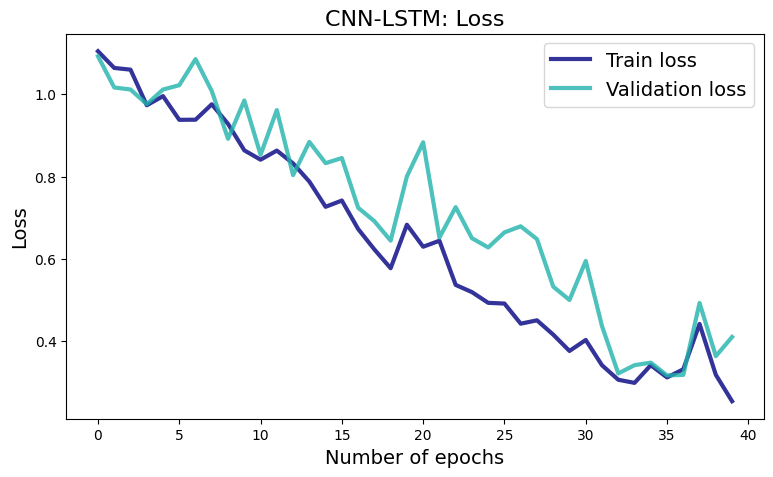

In [173]:
# Visualise loss
generate_performance_graph(value_1=c.history['loss'],
                           value_2=c.history['val_loss'],
                           label_1='Train loss',
                           label_2='Validation loss',
                           title='Loss')

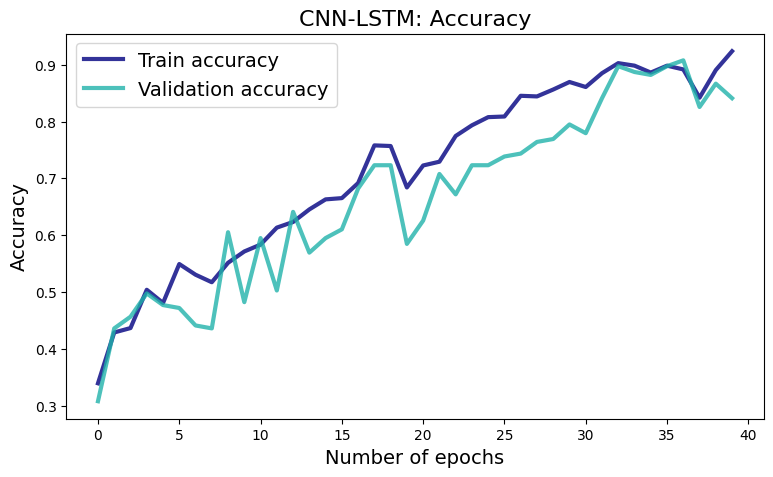

In [174]:
# Visualise accuracy
generate_performance_graph(value_1=c.history['accuracy'],
                           value_2=c.history['val_accuracy'],
                           label_1='Train accuracy',
                           label_2='Validation accuracy',
                           title='Accuracy')

# Evaluation for test data
### 1. Loss and accuracy

In [175]:
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=2)
print(f'Test loss {test_loss:.3f}, Test accuracy: {test_accuracy:.2%}')

7/7 - 0s - 36ms/step - accuracy: 0.8769 - loss: 0.3773
Test loss 0.377, Test accuracy: 87.69%


### 2. Confusion Matrix

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step
Confusion matrix without normalization


array([[62,  6,  0],
       [11, 45,  6],
       [ 0,  1, 64]])

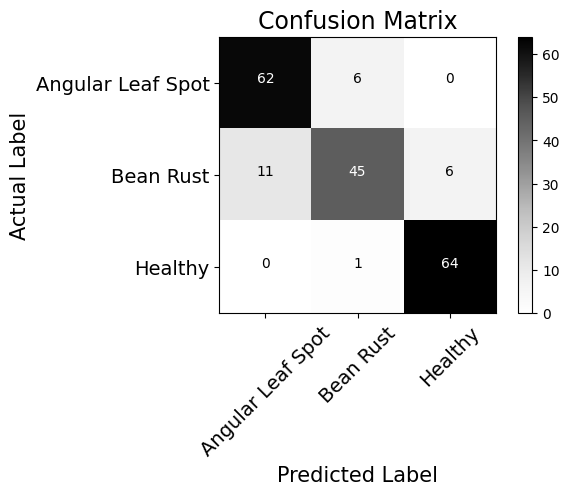

In [176]:
p = np.argmax(model.predict(x_test), axis=1)
#print('Verify accuracy= ', sum(p==y_test)/len(y_test))
cmatrix = produce_confusion_matrix(y_test, p, CLASSES, labels=LABELS)
cmatrix

### 3. F1-Score

In [177]:
get_f_1_score(cmatrix, y_true=y_test, y_hat=p)

Recall score = [0.91176471 0.72580645 0.98461538]
Precision score = [0.84931507 0.86538462 0.91428571]
Unweighted F1 Score: 0.8751938562638646
F1 score for each class :[0.87943262 0.78947368 0.94814815]
Weighted overall F1: 0.8737354691815312


### 4. Mathews correlation coefficients

In [178]:
get_mcc(y=y_test, y_hat=p)

MCC is 0.8173581398170248


### Verify mispredicted sample

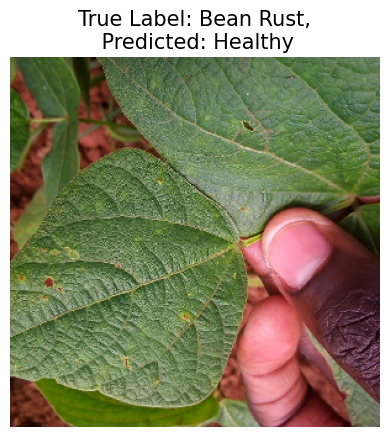

In [182]:
show_mis_predicted_img(prediction=p,labels=LABELS)

In [183]:
# save model : ONLY for the best one!
model.save('Bean-CNN-LSTM_Original.keras')